# AttentionUNet — Salem Mineral Segmentation (PCA Top-3 Features)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1")
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1


### Imports & Reproducibility

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

import rasterio as rio
import geopandas as gpd
from rasterio.mask import mask as rio_mask
from shapely.geometry import mapping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Albumentations for probabilistic augmentation
import albumentations as A

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
_g = torch.Generator()
_g.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


### Configuration

In [3]:
# ── Paths
BASE_DIR  = Path("/content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1")
BASE_NAME = 'LC08_L2SP_143052_20230213_20230218_02_T1'
BASE_NAME_PCA = 'PCA_TOP3'

# PCA component GeoTIFF files (top 3)
PCA_FILES = [
    BASE_DIR / "salem_PC1.tif",
    BASE_DIR / "salem_PC2.tif",
    BASE_DIR / "salem_PC3.tif",
]
SALEM_SHP  = BASE_DIR / 'salem_subdistricts_8.shp'
MASK_NPY   = BASE_DIR / 'salem_valid_mask_8.npy'          # (H, W) bool
LABEL_NPY  = BASE_DIR / 'salem_Minerals_binary_labels_8.npy'

# ── Patch settings
PATCH_SIZE   = 128
STRIDE       = 32
NAN_THRESH   = 0.30

# ── Model
IN_CHANNELS  = 3        # PC1, PC2, PC3
NUM_CLASSES  = 1        # binary segmentation

# ── Training
BATCH_SIZE   = 16
NUM_EPOCHS   = 100
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15     # test = 1 - 0.70 - 0.15 = 0.15

THRESHOLD    = 0.3      # monitoring threshold during training only

# ── Output dirs
PATCH_DIR    = BASE_DIR / 'patches_pca'
CKPT_PATH    = BASE_DIR / 'best_resunet_minerals_pca.pth'
RESULTS_DIR  = BASE_DIR / 'results_pca'

PATCH_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("PCA configuration loaded.")
print(f"  Input channels : {IN_CHANNELS} (PC1, PC2, PC3)")
print(f"  Patch size     : {PATCH_SIZE}×{PATCH_SIZE}")
print(f"  Stride         : {STRIDE}")
print(f"  Train/Val/Test : {TRAIN_SPLIT}/{VAL_SPLIT}/{1-TRAIN_SPLIT-VAL_SPLIT:.2f}")
print(f"  Train threshold: {THRESHOLD}")

PCA configuration loaded.
  Input channels : 3 (PC1, PC2, PC3)
  Patch size     : 128×128
  Stride         : 32
  Train/Val/Test : 0.7/0.15/0.15
  Train threshold: 0.3


### Load PCA Components + Valid Mask + Labels

In [4]:
print("Loading PCA components and masks...")

# ── Load valid mask
valid_mask = np.load(MASK_NPY).astype(bool)          # (H, W)
print(f"  Valid mask shape : {valid_mask.shape}")

# ── Load PCA GeoTIFF files and stack
salem_gdf = gpd.read_file(SALEM_SHP)
cropped_bands = []
landsat_transform = None
landsat_crs       = None
landsat_profile   = None

pca_names = ['PC1', 'PC2', 'PC3']

for i, pca_file in enumerate(PCA_FILES):
    with rio.open(pca_file) as src:
        gdf_proj = salem_gdf.to_crs(src.crs)
        geoms    = [mapping(gdf_proj.geometry.union_all())]
        out_img, out_tf = rio_mask(src, geoms, crop=True, filled=False)
        band_data = out_img[0].astype(np.float32)

        # Handle nodata
        if src.nodata is not None:
            band_data[out_img[0] == src.nodata] = np.nan

        # Apply valid mask (must match shape)
        if band_data.shape == valid_mask.shape:
            band_data[~valid_mask] = np.nan
        else:
            print(f"  WARNING: {pca_names[i]} shape {band_data.shape} != mask {valid_mask.shape}")

        cropped_bands.append(band_data)

        if landsat_transform is None:
            landsat_transform = out_tf
            landsat_crs       = src.crs
            landsat_profile   = src.profile.copy()
            landsat_profile.update({
                'height'   : band_data.shape[0],
                'width'    : band_data.shape[1],
                'count'    : 1,
                'transform': out_tf
            })
        print(f"  Loaded {pca_names[i]} : shape={band_data.shape}, ",
              f"NaN%={np.isnan(band_data).mean()*100:.2f}%")

# Stack to (H, W, 3)
landsat_stack = np.stack(cropped_bands, axis=-1)   # channels-last
H, W, C = landsat_stack.shape
print(f"\nPCA stack shape : {landsat_stack.shape}")
print(f"Valid pixels    : {np.sum(valid_mask):,} ({100*np.sum(valid_mask)/valid_mask.size:.2f}%)")

# ── Load spatial metadata
print("Spatial metadata loaded from PCA GeoTIFFs.")

# ── Load binary labels
binary_labels = np.load(LABEL_NPY).astype(np.uint8)     # (H, W)

if binary_labels.shape != valid_mask.shape:
    raise ValueError(
        f"Shape mismatch! Label {binary_labels.shape} vs mask {valid_mask.shape}."
    )

binary_labels[~valid_mask] = 0

# ── Class statistics
total_px   = int(np.sum(valid_mask))
mineral_px = int(np.sum((binary_labels == 1) & valid_mask))
bg_px      = total_px - mineral_px
ratio      = bg_px / (mineral_px + 1e-8)

print("\nAfter valid-mask application:")
print(f"  Valid pixels    : {total_px:,}")
print(f"  Mineral pixels  : {mineral_px:,} ({mineral_px/total_px*100:.4f}%)")
print(f"  Background px   : {bg_px:,}")
print(f"  Imbalance ratio : {ratio:.0f} : 1")

Loading PCA components and masks...
  Valid mask shape : (2455, 4327)
  Loaded PC1 : shape=(2455, 4327),  NaN%=45.45%
  Loaded PC2 : shape=(2455, 4327),  NaN%=45.45%
  Loaded PC3 : shape=(2455, 4327),  NaN%=45.45%

PCA stack shape : (2455, 4327, 3)
Valid pixels    : 5,794,980 (54.55%)
Spatial metadata loaded from PCA GeoTIFFs.

After valid-mask application:
  Valid pixels    : 5,794,980
  Mineral pixels  : 2,309 (0.0398%)
  Background px   : 5,792,671
  Imbalance ratio : 2509 : 1


### Spatial Block Split + Patch Extraction (No Overlap)

In [5]:
import gc
from sklearn.model_selection import train_test_split

MIN_MINERAL_FRAC   = 0.001  # >=0.5% mineral pixels -> mineral patch
MAX_BG_RATIO       = 2      # max bg patches per mineral patch (per split)
NON_OVERLAP_STRIDE = 64     # 50% overlap during extraction

# -- Augmentation counts
N_AUG_MINERAL = 10   # each mineral patch -> 8 augmented copies
N_AUG_BG      = 3   # each bg patch -> 3 augmented copies (train only)


print('PATCH EXTRACTION -- Non-overlapping stride (zero leakage)')
print(f'  Patch size       : {PATCH_SIZE}x{PATCH_SIZE}')
print(f'  Stride           : {NON_OVERLAP_STRIDE}')
print(f'  Min mineral frac : {MIN_MINERAL_FRAC}')
print(f'  Input channels   : {IN_CHANNELS} (PC1, PC2, PC3)')
print(f'  Mineral aug      : {N_AUG_MINERAL}x per patch (train only)')
print(f'  Background aug   : {N_AUG_BG}x per patch (train only)')
print(f'  Valid mask propagated into every patch -- invalid pixels')
print(f'        excluded from loss, metrics, and confusion matrices.')


# -- Extract ALL valid patches
H_img, W_img = landsat_stack.shape[:2]

all_mineral_imgs, all_mineral_lbls, all_mineral_valid, all_mineral_pos = [], [], [], []
all_bg_imgs,      all_bg_lbls,      all_bg_valid,      all_bg_pos      = [], [], [], []
total_candidates = skipped_nan = 0

for r in range(0, H_img - PATCH_SIZE + 1, NON_OVERLAP_STRIDE):
    for c in range(0, W_img - PATCH_SIZE + 1, NON_OVERLAP_STRIDE):
        total_candidates += 1
        img_p = landsat_stack[r:r+PATCH_SIZE, c:c+PATCH_SIZE, :].copy()
        lbl_p = binary_labels[r:r+PATCH_SIZE, c:c+PATCH_SIZE].copy()

        nan_frac = np.isnan(img_p).any(axis=-1).mean()
        if nan_frac > NAN_THRESH:
            skipped_nan += 1
            continue

        # -- [FIX] Capture per-patch valid pixel mask BEFORE filling NaNs.
        # valid_p is 1 where the pixel comes from real data, 0 where it was NaN
        # (i.e. outside the Salem boundary or raster nodata).
        valid_p = (~np.isnan(img_p).any(axis=-1)).astype(np.uint8)  # (H, W) uint8

        img_p = np.nan_to_num(img_p, nan=0.0)

        if lbl_p.mean() >= MIN_MINERAL_FRAC:
            all_mineral_imgs.append(img_p)
            all_mineral_lbls.append(lbl_p)
            all_mineral_valid.append(valid_p)
            all_mineral_pos.append((r, c))
        elif img_p.max() > 0:
            all_bg_imgs.append(img_p)
            all_bg_lbls.append(lbl_p)
            all_bg_valid.append(valid_p)
            all_bg_pos.append((r, c))

print(f'\nTotal candidates   : {total_candidates}')
print(f'Skipped (NaN>30%)  : {skipped_nan}')
print(f'Mineral patches    : {len(all_mineral_imgs)}')
print(f'Background patches : {len(all_bg_imgs)}')

if len(all_mineral_imgs) == 0:
    raise ValueError('No mineral patches found! Check MIN_MINERAL_FRAC or NAN_THRESH.')


# -- Stratified split of MINERAL patches
mineral_fracs = np.array([lbl.mean() for lbl in all_mineral_lbls])
strat_bins    = np.digitize(mineral_fracs, bins=[0.05, 0.15, 0.30, 0.50])

all_idx = np.arange(len(all_mineral_imgs))

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=(VAL_SPLIT + (1 - TRAIN_SPLIT - VAL_SPLIT)),
    stratify=strat_bins,
    random_state=SEED
)

temp_strat = strat_bins[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=temp_strat,
    random_state=SEED
)

print(f'\nMineral patch split (stratified by mineral fraction):')
print(f'  Train : {len(train_idx):4d}  ({len(train_idx)/len(all_idx)*100:.1f}%)')
print(f'  Val   : {len(val_idx):4d}  ({len(val_idx)/len(all_idx)*100:.1f}%)')
print(f'  Test  : {len(test_idx):4d}  ({len(test_idx)/len(all_idx)*100:.1f}%)')


# -- Verify zero pixel overlap
train_pos_set = set(all_mineral_pos[i] for i in train_idx)
val_pos_set   = set(all_mineral_pos[i] for i in val_idx)
test_pos_set  = set(all_mineral_pos[i] for i in test_idx)

assert len(train_pos_set & val_pos_set)  == 0, 'Train/Val mineral overlap!'
assert len(train_pos_set & test_pos_set) == 0, 'Train/Test mineral overlap!'
assert len(val_pos_set   & test_pos_set) == 0, 'Val/Test mineral overlap!'
print('\n[OK] Zero-overlap verified: no patch origin shared between any two splits.')


# -- Split background patches
rng    = np.random.default_rng(SEED)
bg_idx = rng.permutation(len(all_bg_imgs))

n_bg       = len(bg_idx)
n_bg_train = int(n_bg * TRAIN_SPLIT)
n_bg_val   = int(n_bg * VAL_SPLIT)

bg_train_idx = bg_idx[:n_bg_train]
bg_val_idx   = bg_idx[n_bg_train : n_bg_train + n_bg_val]
bg_test_idx  = bg_idx[n_bg_train + n_bg_val:]

def cap_bg(bg_indices, n_mineral, max_ratio, rng):
    max_bg = min(len(bg_indices), max(max_ratio, max_ratio * n_mineral))
    return rng.choice(bg_indices, size=int(max_bg), replace=False)

bg_train_idx = cap_bg(bg_train_idx, len(train_idx), MAX_BG_RATIO, rng)
bg_val_idx   = cap_bg(bg_val_idx,   len(val_idx),   MAX_BG_RATIO, rng)
bg_test_idx  = cap_bg(bg_test_idx,  len(test_idx),  MAX_BG_RATIO, rng)

print(f'\nBackground patches after cap (max {MAX_BG_RATIO}x mineral):')
print(f'  Train bg : {len(bg_train_idx)}')
print(f'  Val   bg : {len(bg_val_idx)}')
print(f'  Test  bg : {len(bg_test_idx)}')

# -- [FIX] Include valid masks in split_data alongside imgs and lbls
split_data = {
    'train': {
        'mineral_imgs':  [all_mineral_imgs[i]  for i in train_idx],
        'mineral_lbls':  [all_mineral_lbls[i]  for i in train_idx],
        'mineral_valid': [all_mineral_valid[i] for i in train_idx],
        'bg_imgs':       [all_bg_imgs[i]       for i in bg_train_idx],
        'bg_lbls':       [all_bg_lbls[i]       for i in bg_train_idx],
        'bg_valid':      [all_bg_valid[i]      for i in bg_train_idx],
    },
    'val': {
        'mineral_imgs':  [all_mineral_imgs[i]  for i in val_idx],
        'mineral_lbls':  [all_mineral_lbls[i]  for i in val_idx],
        'mineral_valid': [all_mineral_valid[i] for i in val_idx],
        'bg_imgs':       [all_bg_imgs[i]       for i in bg_val_idx],
        'bg_lbls':       [all_bg_lbls[i]       for i in bg_val_idx],
        'bg_valid':      [all_bg_valid[i]      for i in bg_val_idx],
    },
    'test': {
        'mineral_imgs':  [all_mineral_imgs[i]  for i in test_idx],
        'mineral_lbls':  [all_mineral_lbls[i]  for i in test_idx],
        'mineral_valid': [all_mineral_valid[i] for i in test_idx],
        'bg_imgs':       [all_bg_imgs[i]       for i in bg_test_idx],
        'bg_lbls':       [all_bg_lbls[i]       for i in bg_test_idx],
        'bg_valid':      [all_bg_valid[i]      for i in bg_test_idx],
    },
}

print('\n-- Split summary (pre-augmentation) --')
for sname, sd in split_data.items():
    n_min = len(sd['mineral_imgs'])
    n_bg  = len(sd['bg_imgs'])
    print(f'  {sname:5s} | mineral={n_min:4d} | bg={n_bg:4d} | total={n_min+n_bg}')

del all_mineral_imgs, all_mineral_lbls, all_mineral_valid, all_mineral_pos
del all_bg_imgs, all_bg_lbls, all_bg_valid, all_bg_pos
gc.collect()


pca_names_full = ['PC1', 'PC2', 'PC3']

tr_d = split_data['train']
orig_train_imgs  = np.array(tr_d['mineral_imgs']  + tr_d['bg_imgs'],   dtype=np.float32)
orig_train_valid = np.array(tr_d['mineral_valid'] + tr_d['bg_valid'],  dtype=bool)

band_means_list, band_stds_list = [], []
print(f'\nComputing per-component stats from {len(orig_train_imgs)} ORIGINAL train patches...')
print('  Stats computed only over valid (non-NaN) pixels.')
for c in range(IN_CHANNELS):
    vals = orig_train_imgs[:, :, :, c][orig_train_valid]   # [FIX] valid pixels only
    vals = vals[np.isfinite(vals)]
    m    = float(vals.mean())
    s    = float(vals.std()) + 1e-8
    band_means_list.append(m)
    band_stds_list.append(s)
    print(f'  {pca_names_full[c]:<6} | mean = {m:12.6f} | std = {s:12.6f}')

band_means = np.array(band_means_list, dtype=np.float32)
band_stds  = np.array(band_stds_list,  dtype=np.float32)
del orig_train_imgs, orig_train_valid
gc.collect()
print('Normalization stats computed from valid pixels of original (pre-augmentation) train patches.')

import albumentations as A

_aug_pipeline = A.Compose([
    # --- Geometry (safe) ---
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.55),
    A.Transpose(p=0.55),

    # Small arbitrary rotation (forces spatial robustness)
    A.Rotate(limit=20, border_mode=0, p=0.5),

    # Slight scaling (forces scale invariance)
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=0,
        border_mode=0,
        p=0.5
    ),

    # --- Noise (slightly stronger but PCA-safe) ---
    A.GaussNoise(var_limit=(1e-6, 2e-5), p=0.4),

    # Mild elastic deformation (forces boundary learning)
    A.ElasticTransform(
        alpha=1,
        sigma=10,
        alpha_affine=5,
        border_mode=0,
        p=0.3
    ),

], additional_targets={'mask': 'mask', 'valid': 'mask'})

def augment_patches(imgs, lbls, valids, n_augments, seed_offset=0):
    aug_imgs, aug_lbls, aug_valids = [], [], []
    for idx, (img, lbl, valid) in enumerate(zip(imgs, lbls, valids)):
        for k in range(n_augments):
            random.seed(SEED + seed_offset + idx * 100 + k)
            np.random.seed(SEED + seed_offset + idx * 100 + k)
            result = _aug_pipeline(
                image=img,
                mask=lbl.astype(np.uint8),
                valid=valid.astype(np.uint8)   # [FIX] same transforms applied
            )
            aug_imgs.append(result['image'].copy())
            aug_lbls.append(result['mask'].copy())
            aug_valids.append(result['valid'].copy())   # [FIX] retrieve
    return aug_imgs, aug_lbls, aug_valids


# -- Augment TRAIN mineral patches
n_orig_mineral = len(tr_d['mineral_imgs'])

aug_min_imgs, aug_min_lbls, aug_min_valids = augment_patches(
    tr_d['mineral_imgs'], tr_d['mineral_lbls'], tr_d['mineral_valid'],
    n_augments=N_AUG_MINERAL, seed_offset=0
)

tr_min_all_imgs   = list(tr_d['mineral_imgs'])  + aug_min_imgs
tr_min_all_lbls   = list(tr_d['mineral_lbls'])  + aug_min_lbls
tr_min_all_valids = list(tr_d['mineral_valid']) + aug_min_valids

print(f'\nAugmented train MINERAL patches (Albumentations, p=0.5 per transform):')
print(f'  Original : {n_orig_mineral}')
print(f'  Aug only : {len(aug_min_imgs)}  ({N_AUG_MINERAL} copies x {n_orig_mineral})')
print(f'  Total    : {len(tr_min_all_imgs)}  (orig + aug)')


# -- Augment TRAIN background patches
n_orig_bg = len(tr_d['bg_imgs'])

aug_bg_imgs, aug_bg_lbls, aug_bg_valids = augment_patches(
    tr_d['bg_imgs'], tr_d['bg_lbls'], tr_d['bg_valid'],
    n_augments=N_AUG_BG, seed_offset=10000
)

tr_bg_all_imgs   = list(tr_d['bg_imgs'])  + aug_bg_imgs
tr_bg_all_lbls   = list(tr_d['bg_lbls'])  + aug_bg_lbls
tr_bg_all_valids = list(tr_d['bg_valid']) + aug_bg_valids

print(f'\nAugmented train BACKGROUND patches (Albumentations, p=0.5 per transform):')
print(f'  Original : {n_orig_bg}')
print(f'  Aug only : {len(aug_bg_imgs)}  ({N_AUG_BG} copies x {n_orig_bg})')
print(f'  Total    : {len(tr_bg_all_imgs)}  (orig + aug)')

del aug_min_imgs, aug_min_lbls, aug_min_valids
del aug_bg_imgs,  aug_bg_lbls,  aug_bg_valids
gc.collect()


# -- Assemble final arrays (imgs, lbls, valids)
def assemble(min_imgs, min_lbls, min_valids, bg_imgs, bg_lbls, bg_valids):
    imgs   = np.concatenate([np.array(min_imgs,   dtype=np.float32),
                              np.array(bg_imgs,    dtype=np.float32)], axis=0)
    lbls   = np.concatenate([np.array(min_lbls,   dtype=np.uint8),
                              np.array(bg_lbls,    dtype=np.uint8)],   axis=0)
    valids = np.concatenate([np.array(min_valids, dtype=np.uint8),
                              np.array(bg_valids,  dtype=np.uint8)],   axis=0)
    return imgs, lbls, valids


train_imgs, train_lbls, train_valids = assemble(
    tr_min_all_imgs,  tr_min_all_lbls,  tr_min_all_valids,
    tr_bg_all_imgs,   tr_bg_all_lbls,   tr_bg_all_valids
)
val_imgs,   val_lbls,   val_valids   = assemble(
    split_data['val']['mineral_imgs'],  split_data['val']['mineral_lbls'],
    split_data['val']['mineral_valid'],
    split_data['val']['bg_imgs'],       split_data['val']['bg_lbls'],
    split_data['val']['bg_valid'],
)
test_imgs,  test_lbls,  test_valids  = assemble(
    split_data['test']['mineral_imgs'],  split_data['test']['mineral_lbls'],
    split_data['test']['mineral_valid'],
    split_data['test']['bg_imgs'],       split_data['test']['bg_lbls'],
    split_data['test']['bg_valid'],
)

del tr_min_all_imgs, tr_min_all_lbls, tr_min_all_valids
del tr_bg_all_imgs,  tr_bg_all_lbls,  tr_bg_all_valids
del split_data, tr_d
gc.collect()


# -- Build tags and shuffle train
def make_tags(lbl_arr):
    N = len(lbl_arr)
    return (lbl_arr.reshape(N, -1).sum(axis=1) > 0).astype(np.uint8)

train_tags = make_tags(train_lbls)
val_tags   = make_tags(val_lbls)
test_tags  = make_tags(test_lbls)

perm         = np.random.default_rng(SEED).permutation(len(train_imgs))
train_imgs   = train_imgs[perm]
train_lbls   = train_lbls[perm]
train_valids = train_valids[perm]
train_tags   = train_tags[perm]

# -- Report valid pixel coverage per split
def valid_px_stats(valids, name):
    total_px   = valids.size
    valid_px   = int(valids.sum())
    invalid_px = total_px - valid_px
    print(f'  {name:5s} | patches={len(valids):4d} | '
          f'total px={total_px:>10,} | valid px={valid_px:>10,} '
          f'({valid_px/total_px*100:.1f}%) | invalid px={invalid_px:>8,}')

print('\n-- Final dataset sizes --')
print(f'  Train : {len(train_imgs):>5} patches | '
      f'mineral={train_tags.sum():>4} ({train_tags.mean()*100:.1f}%) | '
      f'bg={len(train_imgs)-train_tags.sum()}')
print(f'  Val   : {len(val_imgs):>5} patches | '
      f'mineral={val_tags.sum():>4} ({val_tags.mean()*100:.1f}%) | '
      f'bg={len(val_imgs)-val_tags.sum()}')
print(f'  Test  : {len(test_imgs):>5} patches | '
      f'mineral={test_tags.sum():>4} ({test_tags.mean()*100:.1f}%) | '
      f'bg={len(test_imgs)-test_tags.sum()}')

print(f'\n  Train breakdown:')
print(f'    Mineral : {n_orig_mineral} orig + {n_orig_mineral * N_AUG_MINERAL} aug = {n_orig_mineral * (1 + N_AUG_MINERAL)}')
print(f'    Bg      : {n_orig_bg} orig + {n_orig_bg * N_AUG_BG} aug = {n_orig_bg * (1 + N_AUG_BG)}')
print(f'\n  Val and Test : ONLY original unaugmented patches from non-overlapping splits.')

print('\n-- [FIX] Valid pixel coverage per split (shows how many border pixels are excluded) --')
valid_px_stats(train_valids, 'Train')
valid_px_stats(val_valids,   'Val')
valid_px_stats(test_valids,  'Test')

# -- Save arrays (including valid masks)
PATCH_DIR.mkdir(exist_ok=True)
np.save(PATCH_DIR / 'train_imgs_pca.npy',   train_imgs)
np.save(PATCH_DIR / 'train_lbls_pca.npy',   train_lbls)
np.save(PATCH_DIR / 'train_valids_pca.npy', train_valids)  # [FIX] new
np.save(PATCH_DIR / 'val_imgs_pca.npy',     val_imgs)
np.save(PATCH_DIR / 'val_lbls_pca.npy',     val_lbls)
np.save(PATCH_DIR / 'val_valids_pca.npy',   val_valids)    # [FIX] new
np.save(PATCH_DIR / 'test_imgs_pca.npy',    test_imgs)
np.save(PATCH_DIR / 'test_lbls_pca.npy',    test_lbls)
np.save(PATCH_DIR / 'test_valids_pca.npy',  test_valids)   # [FIX] new
np.save(PATCH_DIR / 'pca_means.npy', band_means)
np.save(PATCH_DIR / 'pca_stds.npy',  band_stds)
print('\nAll arrays and normalization stats saved (including valid masks).')


PATCH EXTRACTION -- Non-overlapping stride (zero leakage)
  Patch size       : 128x128
  Stride           : 64
  Min mineral frac : 0.001
  Input channels   : 3 (PC1, PC2, PC3)
  Mineral aug      : 10x per patch (train only)
  Background aug   : 3x per patch (train only)
  Valid mask propagated into every patch -- invalid pixels
        excluded from loss, metrics, and confusion matrices.

Total candidates   : 2442
Skipped (NaN>30%)  : 1126
Mineral patches    : 127
Background patches : 1189

Mineral patch split (stratified by mineral fraction):
  Train :   88  (69.3%)
  Val   :   19  (15.0%)
  Test  :   20  (15.7%)

[OK] Zero-overlap verified: no patch origin shared between any two splits.

Background patches after cap (max 2x mineral):
  Train bg : 176
  Val   bg : 38
  Test  bg : 40

-- Split summary (pre-augmentation) --
  train | mineral=  88 | bg= 176 | total=264
  val   | mineral=  19 | bg=  38 | total=57
  test  | mineral=  20 | bg=  40 | total=60

Computing per-component stats 

### Dataset & DataLoaders

In [6]:
class MineralDataset(Dataset):
    def __init__(self, images, labels, valids, band_means, band_stds):
        self.images = images
        self.labels = labels
        self.valids = valids
        self.means  = band_means.reshape(1, 1, -1)    # (1,1,3) for broadcasting
        self.stds   = band_stds.reshape(1, 1, -1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        image = self.images[i].astype(np.float32).copy()
        label = self.labels[i].astype(np.float32).copy()
        valid = self.valids[i].astype(np.float32).copy()   # [FIX]

        # Z-score normalisation using PCA component stats
        image = (image - self.means) / self.stds

        img_t   = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        lbl_t   = torch.from_numpy(label).unsqueeze(0).contiguous().float()
        valid_t = torch.from_numpy(valid).unsqueeze(0).contiguous().float()   # [FIX]

        return img_t, lbl_t, valid_t   # [FIX] three-item return


train_ds = MineralDataset(train_imgs, train_lbls, train_valids, band_means, band_stds)
val_ds   = MineralDataset(val_imgs,   val_lbls,   val_valids,   band_means, band_stds)
test_ds  = MineralDataset(test_imgs,  test_lbls,  test_valids,  band_means, band_stds)

train_gen = torch.Generator()
train_gen.manual_seed(SEED)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, generator=train_gen)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'DataLoaders ready:')
print(f'  Train : {len(train_ds)} patches')
print(f'  Val   : {len(val_ds)} patches')
print(f'  Test  : {len(test_ds)} patches')

img_b, lbl_b, val_b = next(iter(train_loader))   # [FIX] unpack three items
print(f'  Batch image shape : {img_b.shape}  (B, {IN_CHANNELS}, H, W)')
print(f'  Batch label shape : {lbl_b.shape}')
print(f'  Batch valid shape : {val_b.shape}  1=real pixel, 0=invalid border')
del img_b, lbl_b, val_b
gc.collect()


DataLoaders ready:
  Train : 1672 patches
  Val   : 57 patches
  Test  : 60 patches
  Batch image shape : torch.Size([16, 3, 128, 128])  (B, 3, H, W)
  Batch label shape : torch.Size([16, 1, 128, 128])
  Batch valid shape : torch.Size([16, 1, 128, 128])  1=real pixel, 0=invalid border


0

### AttentionUNet Architecture

In [7]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.block = nn.Sequential(
            ConvBNReLU(in_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )
        self.drop = nn.Dropout2d(p=dropout_p) if dropout_p > 0.0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.block(x))


class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, int_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, int_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(int_ch)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, int_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(int_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(int_ch, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g_up = F.interpolate(self.W_g(g), size=x.shape[2:],
                             mode='bilinear', align_corners=False)
        att  = self.relu(g_up + self.W_x(x))
        att  = self.psi(att)
        return x * att


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch, dropout_p=dropout_p)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        feat   = self.conv(x)
        pooled = self.pool(feat)
        return feat, pooled


class AttentionDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout_p=0.0):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.att  = AttentionGate(
            g_ch    = out_ch,
            x_ch    = skip_ch,
            int_ch  = max(out_ch // 2, 16)
        )
        self.conv = DoubleConv(out_ch + skip_ch, out_ch, dropout_p=dropout_p)

    def forward(self, x, skip):
        x    = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode='bilinear', align_corners=False)
        skip = self.att(g=x, x=skip)
        x    = torch.cat([x, skip], dim=1)
        return self.conv(x)


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=7, features=[32, 64, 128, 256, 512]):
        super().__init__()
        # ── Encoder:
        self.enc1   = EncoderBlock(in_channels, features[0])
        self.enc2   = EncoderBlock(features[0], features[1])
        self.enc3   = EncoderBlock(features[1], features[2], dropout_p=0.1)
        self.enc4   = EncoderBlock(features[2], features[3], dropout_p=0.2)
        # ── Bottleneck
        self.bridge = DoubleConv(features[3], features[4], dropout_p=0.2)
        # ── Decoder:
        self.dec4   = AttentionDecoderBlock(features[4], features[3], features[3])
        self.dec3   = AttentionDecoderBlock(features[3], features[2], features[2])
        self.dec2   = AttentionDecoderBlock(features[2], features[1], features[1])
        self.dec1   = AttentionDecoderBlock(features[1], features[0], features[0], dropout_p=0.1)
        # ── Output
        self.out    = nn.Conv2d(features[0], 1, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        s1, x = self.enc1(x)
        s2, x = self.enc2(x)
        s3, x = self.enc3(x)
        s4, x = self.enc4(x)
        x     = self.bridge(x)
        x     = self.dec4(x, s4)
        x     = self.dec3(x, s3)
        x     = self.dec2(x, s2)
        x     = self.dec1(x, s1)
        return self.out(x)


# ── Instantiate
model = AttentionUNet(in_channels=IN_CHANNELS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
att_params   = sum(p.numel() for n, p in model.named_parameters() if 'att' in n)
print(f"Model             : Attention U-Net  (matched to UNet scale)")
print(f"Total Parameters  : {total_params:,}")
print(f"Attention params  : {att_params:,}  ({att_params/total_params*100:.1f}% overhead)")
print(f"Encoder dropout   : enc3=0.1 | enc4=0.2")
print(f"Bridge dropout    : 0.2")
print(f"Decoder dropout   : dec1=0.05 | dec2/3/4=0.0")
print(f"Attention int_ch  : dec4={max(256//2,16)} | dec3={max(128//2,16)} | dec2={max(64//2,16)} | dec1={max(32//2,16)}")

with torch.no_grad():
    dummy = torch.zeros(2, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Forward pass OK   : {dummy.shape} → {out.shape}")

Model             : Attention U-Net  (matched to UNet scale)
Total Parameters  : 7,851,289
Attention params  : 88,248  (1.1% overhead)
Encoder dropout   : enc3=0.1 | enc4=0.2
Bridge dropout    : 0.2
Decoder dropout   : dec1=0.05 | dec2/3/4=0.0
Attention int_ch  : dec4=128 | dec3=64 | dec2=32 | dec1=16
Forward pass OK   : torch.Size([2, 3, 128, 128]) → torch.Size([2, 1, 128, 128])


### Loss Function (Weighted BCE + Dice)

In [8]:
class BCEDiceLoss(nn.Module):
    def __init__(self, pos_weight=45.0, bce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super().__init__()
        self.register_buffer('pos_weight', torch.tensor([pos_weight], dtype=torch.float32))
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.smooth      = smooth

    def forward(self, logits, targets, valid_mask=None):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.float()

        # Masked BCE: zero out invalid pixels, average over valid only
        pw = self.pos_weight.expand_as(targets)
        bce_raw = F.binary_cross_entropy_with_logits(
            logits, targets, weight=None, reduction='none', pos_weight=pw
        )
        if valid_mask is not None:
            bce_loss = (bce_raw * valid_mask).sum() / (valid_mask.sum() + 1e-8)
        else:
            bce_loss = bce_raw.mean()

        # Masked Dice: restrict sums to valid pixels only
        probs = torch.sigmoid(logits)
        dims  = (1, 2, 3)
        if valid_mask is not None:
            probs_v   = probs   * valid_mask
            targets_v = targets * valid_mask
        else:
            probs_v   = probs
            targets_v = targets

        intersection = (probs_v * targets_v).sum(dims)
        cardinality  = probs_v.sum(dims) + targets_v.sum(dims)
        dice_loss    = 1.0 - ((2.0 * intersection + self.smooth) /
                               (cardinality + self.smooth)).mean()

        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


criterion = BCEDiceLoss(pos_weight=45.0, bce_weight=0.5, dice_weight=0.5).to(DEVICE)
print("Loss: Weighted BCE + Dice  (pos_weight=45, bce=0.5, dice=0.5)")

Loss: Weighted BCE + Dice  (pos_weight=45, bce=0.5, dice=0.5)


### Metrics

In [9]:
class RunningMetrics:
    """Accumulates TP/FP/FN/TN counts across batches — O(1) memory."""
    def __init__(self):
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = self.tn = 0
        self.total_loss = 0.0
        self.n_batches  = 0

    def update(self, preds_bin, targets, valid_mask=None, loss_val=0.0):   # [FIX]
        p = preds_bin.reshape(-1).astype(np.int32)
        t = targets.reshape(-1).astype(np.int32)

        # [FIX] Restrict counting to valid pixels only
        if valid_mask is not None:
            v = valid_mask.reshape(-1).astype(bool)
            p, t = p[v], t[v]

        self.tp += int(((p == 1) & (t == 1)).sum())
        self.fp += int(((p == 1) & (t == 0)).sum())
        self.fn += int(((p == 0) & (t == 1)).sum())
        self.tn += int(((p == 0) & (t == 0)).sum())
        self.total_loss += loss_val
        self.n_batches  += 1

    def compute(self, smooth=1e-8):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        precision   = (tp + smooth) / (tp + fp + smooth)
        recall      = (tp + smooth) / (tp + fn + smooth)
        f1          = 2 * precision * recall / (precision + recall + smooth)
        mineral_iou = (tp + smooth) / (tp + fp + fn + smooth)
        bg_iou      = (tn + smooth) / (tn + fp + fn + smooth)
        mean_iou    = (mineral_iou + bg_iou) / 2
        pixel_acc   = (tp + tn) / (tp + fp + fn + tn + smooth)
        avg_loss    = self.total_loss / max(self.n_batches, 1)
        return avg_loss, float(pixel_acc), float(mean_iou), float(mineral_iou), \
               float(precision), float(recall), float(f1)


def evaluate_efficient(model, loader, criterion, threshold, device=DEVICE):
    """Validation / test loop — no list accumulation, O(1) extra memory."""
    model.eval()
    metrics = RunningMetrics()

    with torch.no_grad():
        for imgs, lbls, valids in loader:   # [FIX] unpack three items
            imgs   = imgs.to(device)
            lbls   = lbls.to(device)
            valids = valids.to(device)      # [FIX]

            logits    = model(imgs)
            loss      = criterion(logits, lbls, valids)   # [FIX] pass valid mask
            probs     = torch.sigmoid(logits)
            preds_bin = (probs > threshold).float()

            metrics.update(
                preds_bin.cpu().numpy(),
                lbls.cpu().numpy(),
                valids.cpu().numpy(),   # [FIX]
                loss.item()
            )

            del imgs, lbls, valids, logits, probs, preds_bin
            torch.cuda.empty_cache()

    return metrics.compute()


print("Metrics defined. Primary metric: Mineral IoU")
print("All metric computations now exclude invalid (NaN-filled) pixels.")


Metrics defined. Primary metric: Mineral IoU
All metric computations now exclude invalid (NaN-filled) pixels.


### Optimizer & Scheduler

In [10]:
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)

scheduler = ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

print("Optimizer : AdamW  (lr=5e-4, weight_decay=1e-4)")
print("Scheduler : ReduceLROnPlateau (monitoring val Mineral IoU)")

Optimizer : AdamW  (lr=5e-4, weight_decay=1e-4)
Scheduler : ReduceLROnPlateau (monitoring val Mineral IoU)


### Training Loop

In [11]:
import gc

BEST_THRESHOLD = THRESHOLD
print(f"  Initial BEST_THRESHOLD = {BEST_THRESHOLD:.2f}  (will be refined after training)")

# -- Training loop
history = {
    'train_loss': [], 'val_loss': [],
    'train_miou': [], 'val_miou': [],
    'train_min_iou': [], 'val_min_iou': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [],    'val_recall': [],
    'train_f1': [],        'val_f1': []
}

best_val_mineral_iou = 0.0
patience_count       = 0
EARLY_STOP           = 20

gc.collect()
torch.cuda.empty_cache()

print(f"\nTraining AttentionUNet (PCA-3) | Device: {DEVICE}")
print(f"Primary metric: Mineral IoU  |  Monitoring threshold: {THRESHOLD}")
print("Invalid pixels excluded from loss and metrics in every batch.\n")

for epoch in range(1, NUM_EPOCHS + 1):

    # -- Train phase
    model.train()
    train_metrics = RunningMetrics()

    loop = tqdm(train_loader,
                desc=f"Ep {epoch:3d}/{NUM_EPOCHS} [Train]",
                leave=False, ncols=100)

    for imgs, lbls, valids in loop:   # [FIX] unpack three items
        imgs   = imgs.to(DEVICE)
        lbls   = lbls.to(DEVICE)
        valids = valids.to(DEVICE)    # [FIX]

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, lbls, valids)   # [FIX] pass valid mask to loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        loss_val = loss.item()

        with torch.no_grad():
            probs     = torch.sigmoid(logits)
            preds_bin = (probs > THRESHOLD).float()
            train_metrics.update(
                preds_bin.cpu().numpy(),
                lbls.cpu().numpy(),
                valids.cpu().numpy(),   # [FIX] pass valid mask to metrics
                loss_val
            )

        del imgs, lbls, valids, logits, probs, preds_bin, loss
        torch.cuda.empty_cache()
        loop.set_postfix(loss=f"{loss_val:.4f}")

    (train_loss, t_acc, t_miou,
     t_min_iou, t_precision, t_recall, t_f1) = train_metrics.compute()

    # -- Validation phase
    (val_loss, v_acc, v_miou,
     v_min_iou, v_precision, v_recall, v_f1) = evaluate_efficient(
        model, val_loader, criterion,
        threshold=THRESHOLD, device=DEVICE
    )

    scheduler.step(v_min_iou)

    history['train_loss'].append(train_loss);       history['val_loss'].append(val_loss)
    history['train_miou'].append(t_miou);           history['val_miou'].append(v_miou)
    history['train_min_iou'].append(t_min_iou);     history['val_min_iou'].append(v_min_iou)
    history['train_precision'].append(t_precision); history['val_precision'].append(v_precision)
    history['train_recall'].append(t_recall);       history['val_recall'].append(v_recall)
    history['train_f1'].append(t_f1);               history['val_f1'].append(v_f1)

    print(
        f"Ep {epoch:3d} | "
        f"Loss {train_loss:.4f}/{val_loss:.4f} | "
        f"MinIoU {t_min_iou*100:.2f}%/{v_min_iou*100:.2f}% | "
        f"Prec {v_precision*100:.2f}% | "
        f"Rec {v_recall*100:.2f}% | "
        f"F1 {v_f1*100:.2f}%"
    )

    if v_min_iou > best_val_mineral_iou:
        best_val_mineral_iou = v_min_iou
        torch.save(model.state_dict(), CKPT_PATH)
        print(f"   [OK] Best model saved (Val MinIoU={v_min_iou*100:.2f}% @ thr={THRESHOLD})")
        patience_count = 0
    else:
        patience_count += 1
        print(f"   [Patience {patience_count}/{EARLY_STOP}]")
        if patience_count >= EARLY_STOP:
            print("\nEarly stopping triggered.")
            break

    gc.collect()
    torch.cuda.empty_cache()

print(f"\nBest Validation Mineral IoU (@ thr={THRESHOLD}): {best_val_mineral_iou*100:.2f}%")

# Reload best weights
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print("Best checkpoint reloaded.")


  Initial BEST_THRESHOLD = 0.30  (will be refined after training)

Training AttentionUNet (PCA-3) | Device: cuda
Primary metric: Mineral IoU  |  Monitoring threshold: 0.3
Invalid pixels excluded from loss and metrics in every batch.



Ep   1 | Loss 0.9592/0.6351 | MinIoU 0.28%/0.42% | Prec 0.43% | Rec 17.12% | F1 0.84%
   [OK] Best model saved (Val MinIoU=0.42% @ thr=0.3)


Ep   2 | Loss 0.6807/0.6183 | MinIoU 0.53%/0.99% | Prec 1.01% | Rec 30.45% | F1 1.95%
   [OK] Best model saved (Val MinIoU=0.99% @ thr=0.3)


Ep   3 | Loss 0.6611/0.6056 | MinIoU 0.80%/1.17% | Prec 1.18% | Rec 51.30% | F1 2.31%
   [OK] Best model saved (Val MinIoU=1.17% @ thr=0.3)


Ep   4 | Loss 0.6520/0.5940 | MinIoU 1.00%/1.99% | Prec 2.08% | Rec 31.59% | F1 3.91%
   [OK] Best model saved (Val MinIoU=1.99% @ thr=0.3)


...

Ep  96 | Loss 0.2301/0.4060 | MinIoU 90.54%/85.87% | Prec 93.08% | Rec 91.72% | F1 92.40%
   [Patience 2/20]


Ep  97 | Loss 0.2299/0.4058 | MinIoU 90.43%/85.89% | Prec 92.91% | Rec 91.91% | F1 92.41%
   [Patience 3/20]


Ep  98 | Loss 0.2303/0.4060 | MinIoU 90.29%/86.04% | Prec 93.09% | Rec 91.91% | F1 92.50%
   [Patience 4/20]


Ep  99 | Loss 0.2288/0.4059 | MinIoU 90.86%/86.93% | Prec 94.06% | Rec 91.98% | F1 93.01%
   [OK] Best model saved (Val MinIoU=86.93% @ thr=0.3)


Ep 100 | Loss 0.2300/0.4054 | MinIoU 90.61%/86.32% | Prec 93.28% | Rec 92.04% | F1 92.66%
   [Patience 1/20]

Best Validation Mineral IoU (@ thr=0.3): 86.93%
Best checkpoint reloaded.


### Training Curves

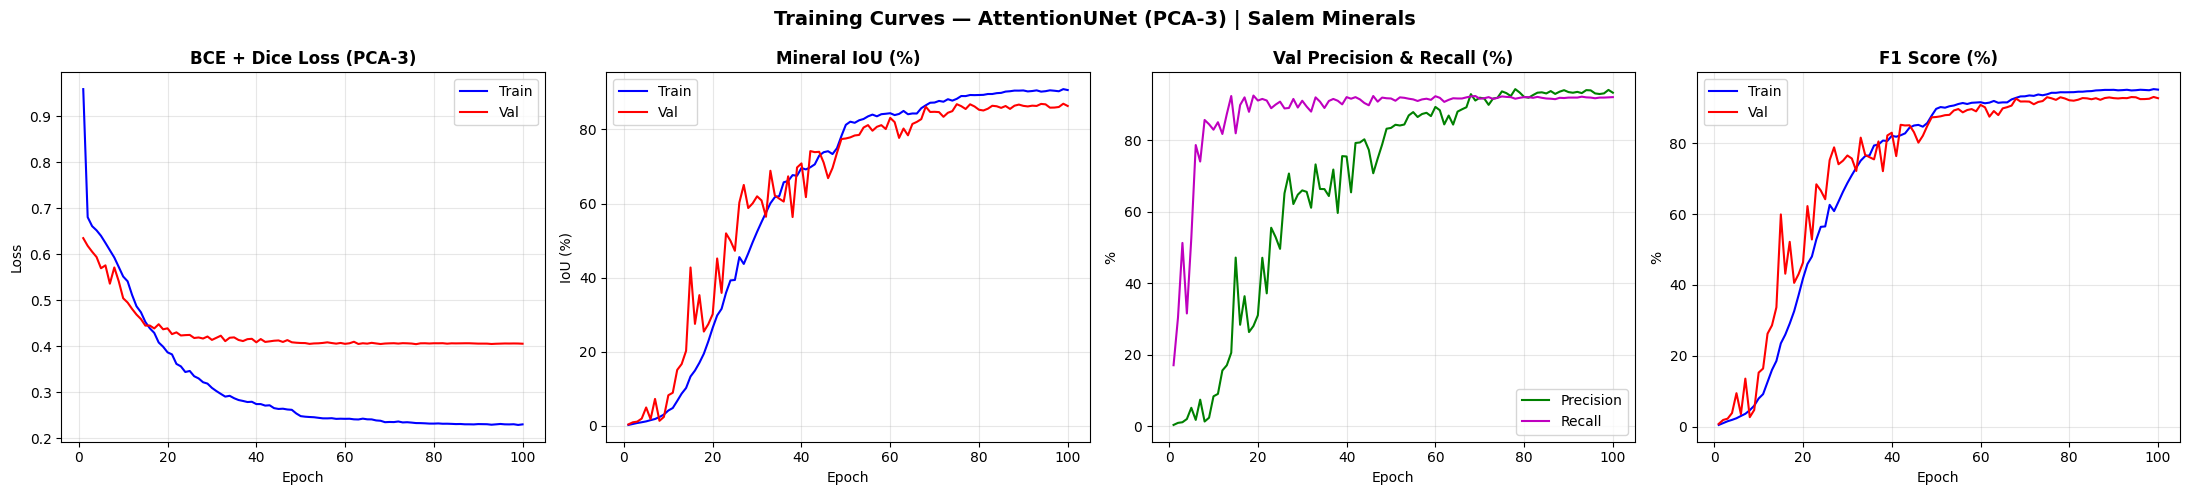

In [12]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0].plot(ep, history['val_loss'],   'r-', label='Val')
axes[0].set_title('BCE + Dice Loss (PCA-3)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [v*100 for v in history['train_min_iou']], 'b-', label='Train')
axes[1].plot(ep, [v*100 for v in history['val_min_iou']],   'r-', label='Val')
axes[1].set_title('Mineral IoU (%)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, [v*100 for v in history['val_precision']], 'g-', label='Precision')
axes[2].plot(ep, [v*100 for v in history['val_recall']],    'm-', label='Recall')
axes[2].set_title('Val Precision & Recall (%)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('%')
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(ep, [v*100 for v in history['train_f1']], 'b-', label='Train')
axes[3].plot(ep, [v*100 for v in history['val_f1']],   'r-', label='Val')
axes[3].set_title('F1 Score (%)', fontweight='bold')
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('%')
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.suptitle('Training Curves — AttentionUNet (PCA-3) | Salem Minerals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Threshold Search on Validation Set

In [13]:
# No threshold search — use the same threshold as training
BEST_THRESHOLD = THRESHOLD
print(f"Using fixed training threshold: BEST_THRESHOLD = {BEST_THRESHOLD:.2f}")

Using fixed training threshold: BEST_THRESHOLD = 0.30


### Test Set Evaluation

In [14]:
# ── Results at FIXED threshold (baseline, no val-set optimisation)
(fix_loss, fix_acc, fix_miou, fix_min_iou,
 fix_precision, fix_recall, fix_f1) = evaluate_efficient(
    model, test_loader, criterion,
    threshold=THRESHOLD, device=DEVICE
)

print(" TEST SET RESULTS — Raw 7-Band AttentionUNet")

print(f"\n── At FIXED threshold = {THRESHOLD:.2f}  [Baseline — no val optimisation] ──")
print(f"  ★ Mineral IoU (PRIMARY) : {fix_min_iou*100:.2f}%")
print(f"  ★ F1 Score   (PRIMARY)  : {fix_f1*100:.2f}%")
print(f"  ★ Recall                : {fix_recall*100:.2f}%")
print(f"  ★ Precision             : {fix_precision*100:.2f}%")
print(f"    Mean IoU  (secondary) : {fix_miou*100:.2f}%")
print(f"    Loss                  : {fix_loss:.4f}")
print(f"    Pixel Acc (secondary,")
print(f"    background-dominated) : {fix_acc*100:.2f}%  ← misleading for imbalanced data")

 TEST SET RESULTS — Raw 7-Band AttentionUNet

── At FIXED threshold = 0.30  [Baseline — no val optimisation] ──
  ★ Mineral IoU (PRIMARY) : 85.04%
  ★ F1 Score   (PRIMARY)  : 91.91%
  ★ Recall                : 90.00%
  ★ Precision             : 93.91%
    Mean IoU  (secondary) : 92.51%
    Loss                  : 0.3920
    Pixel Acc (secondary,
    background-dominated) : 99.98%  ← misleading for imbalanced data


### Visualize Test Patch Predictions

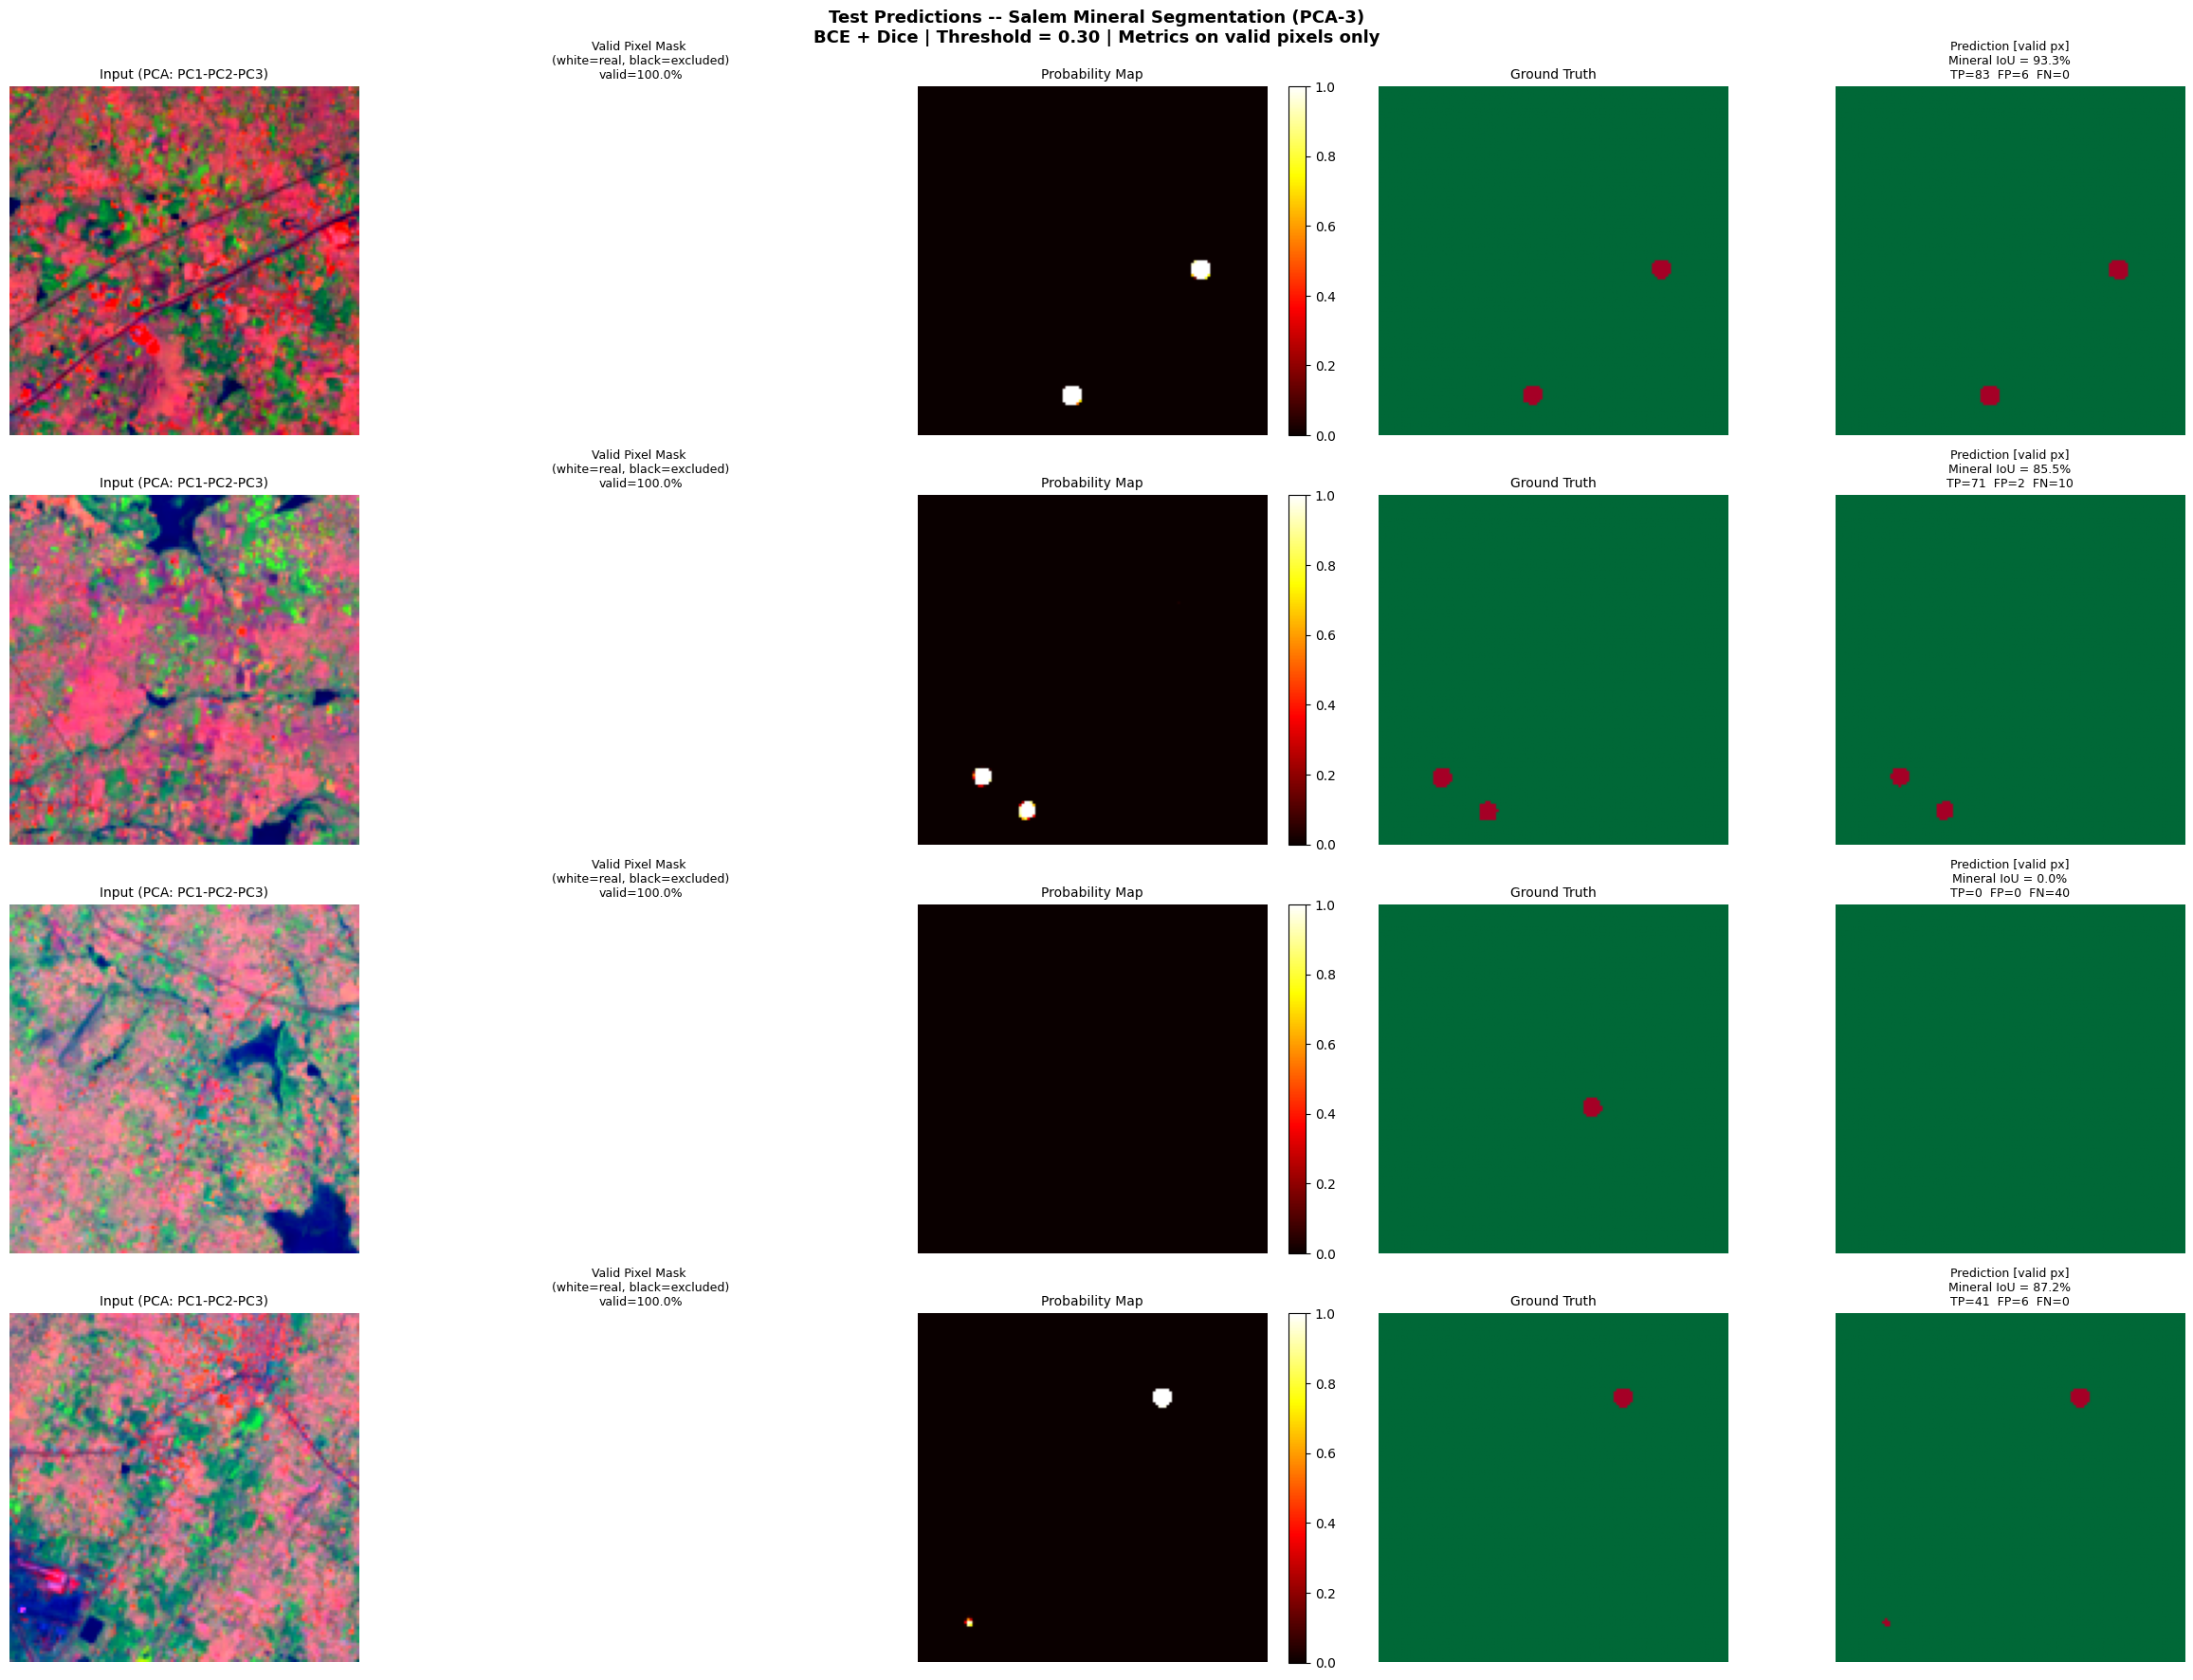

In [15]:
mineral_test_idx = [
    i for i in range(len(test_ds))
    if test_ds.labels[i].sum() > 0
]

n_show = min(4, len(mineral_test_idx))
if n_show == 0:
    print("No mineral patches in test set to visualize.")
else:
    sample = random.sample(mineral_test_idx, n_show)
    # [FIX] 5 columns: input | valid mask | prob map | ground truth | prediction
    fig, axes = plt.subplots(n_show, 5, figsize=(24, n_show * 4.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    model.eval()
    for row, i in enumerate(sample):
        img_t, lbl_t, valid_t = test_ds[i]   # [FIX] unpack three items
        img_t = img_t.to(DEVICE)

        with torch.no_grad():
            logits = model(img_t.unsqueeze(0))
            prob   = torch.sigmoid(logits).squeeze().cpu().numpy()

        pred_bin = (prob > BEST_THRESHOLD).astype(np.uint8)
        lbl_np   = lbl_t.squeeze().cpu().numpy()
        valid_np = valid_t.squeeze().numpy().astype(bool)

        # Undo normalisation - PCA pseudo-RGB (PC1=R, PC2=G, PC3=B)
        img_np  = img_t.cpu().permute(1, 2, 0).numpy() * band_stds + band_means
        rgb_vis = img_np[:, :, :3]
        p2, p98 = np.percentile(rgb_vis, (2, 98))
        rgb_vis = np.clip((rgb_vis - p2) / (p98 - p2 + 1e-8), 0, 1)

        # Col 0: Input image
        axes[row, 0].imshow(rgb_vis)
        axes[row, 0].set_title("Input (PCA: PC1-PC2-PC3)", fontsize=10)
        axes[row, 0].axis("off")

        # Col 1: [FIX] Valid pixel mask
        axes[row, 1].imshow(valid_np, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title(
            f"Valid Pixel Mask \n(white=real, black=excluded)\n"
            f"valid={valid_np.mean()*100:.1f}%", fontsize=9
        )
        axes[row, 1].axis("off")

        # Col 2: Probability map
        im = axes[row, 2].imshow(prob, cmap="hot", vmin=0, vmax=1)
        axes[row, 2].set_title("Probability Map", fontsize=10)
        axes[row, 2].axis("off")
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

        # Col 3: Ground truth
        axes[row, 3].imshow(lbl_np, cmap="RdYlGn_r", vmin=0, vmax=1)
        axes[row, 3].set_title("Ground Truth", fontsize=10)
        axes[row, 3].axis("off")

        # Col 4: Prediction -- [FIX] IoU computed on valid pixels only
        p_v = pred_bin[valid_np]
        t_v = lbl_np[valid_np].astype(np.uint8)
        tp_p = int(((p_v == 1) & (t_v == 1)).sum())
        fp_p = int(((p_v == 1) & (t_v == 0)).sum())
        fn_p = int(((p_v == 0) & (t_v == 1)).sum())
        iou_p = tp_p / (tp_p + fp_p + fn_p + 1e-8)

        axes[row, 4].imshow(pred_bin, cmap="RdYlGn_r", vmin=0, vmax=1)
        axes[row, 4].set_title(
            f"Prediction [valid px]\nMineral IoU = {iou_p*100:.1f}%\nTP={tp_p}  FP={fp_p}  FN={fn_p}",
            fontsize=9
        )
        axes[row, 4].axis("off")

    plt.suptitle(
        f"Test Predictions -- Salem Mineral Segmentation (PCA-3)\n"
        f"BCE + Dice | Threshold = {BEST_THRESHOLD:.2f} | Metrics on valid pixels only",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "test_mineral_patches_pca.png", dpi=150, bbox_inches="tight")
    plt.show()


### Confusion Matrices — Train, Val & Test

   25,636,371 / 27,394,048 pixels used (93.6% valid, 1,757,677 excluded)
   918,171 / 933,888 pixels used (98.3% valid, 15,717 excluded)
   976,662 / 983,040 pixels used (99.4% valid, 6,378 excluded)
 CONFUSION MATRIX REPORT — PCA-3 AttentionUNet
 Threshold = 0.30
 Counts reflect valid (non-NaN) pixels only


── TRAIN SET (25,636,371 valid pixels) ──
  True BG  → TN=  25,567,906   FP=       5,086
  True Min → FN=          55   TP=      63,324

  Accuracy    : 99.9799%
  Precision   : 92.5654%
  Recall      : 99.9132%
  Specificity : 99.9801%
  F1 Score    : 96.0991%
  Mineral IoU : 92.4911%
  Mean IoU    : 96.2355%

── VAL SET (918,171 valid pixels) ──
  True BG  → TN=     916,496   FP=          92
  True Min → FN=         127   TP=       1,456

  Accuracy    : 99.9761%
  Precision   : 94.0568%
  Recall      : 91.9773%
  Specificity : 99.9900%
  F1 Score    : 93.0054%
  Mineral IoU : 86.9254%
  Mean IoU    : 93.4507%

── TEST SET (976,662 valid pixels) ──
  True BG  → TN=     975,392  

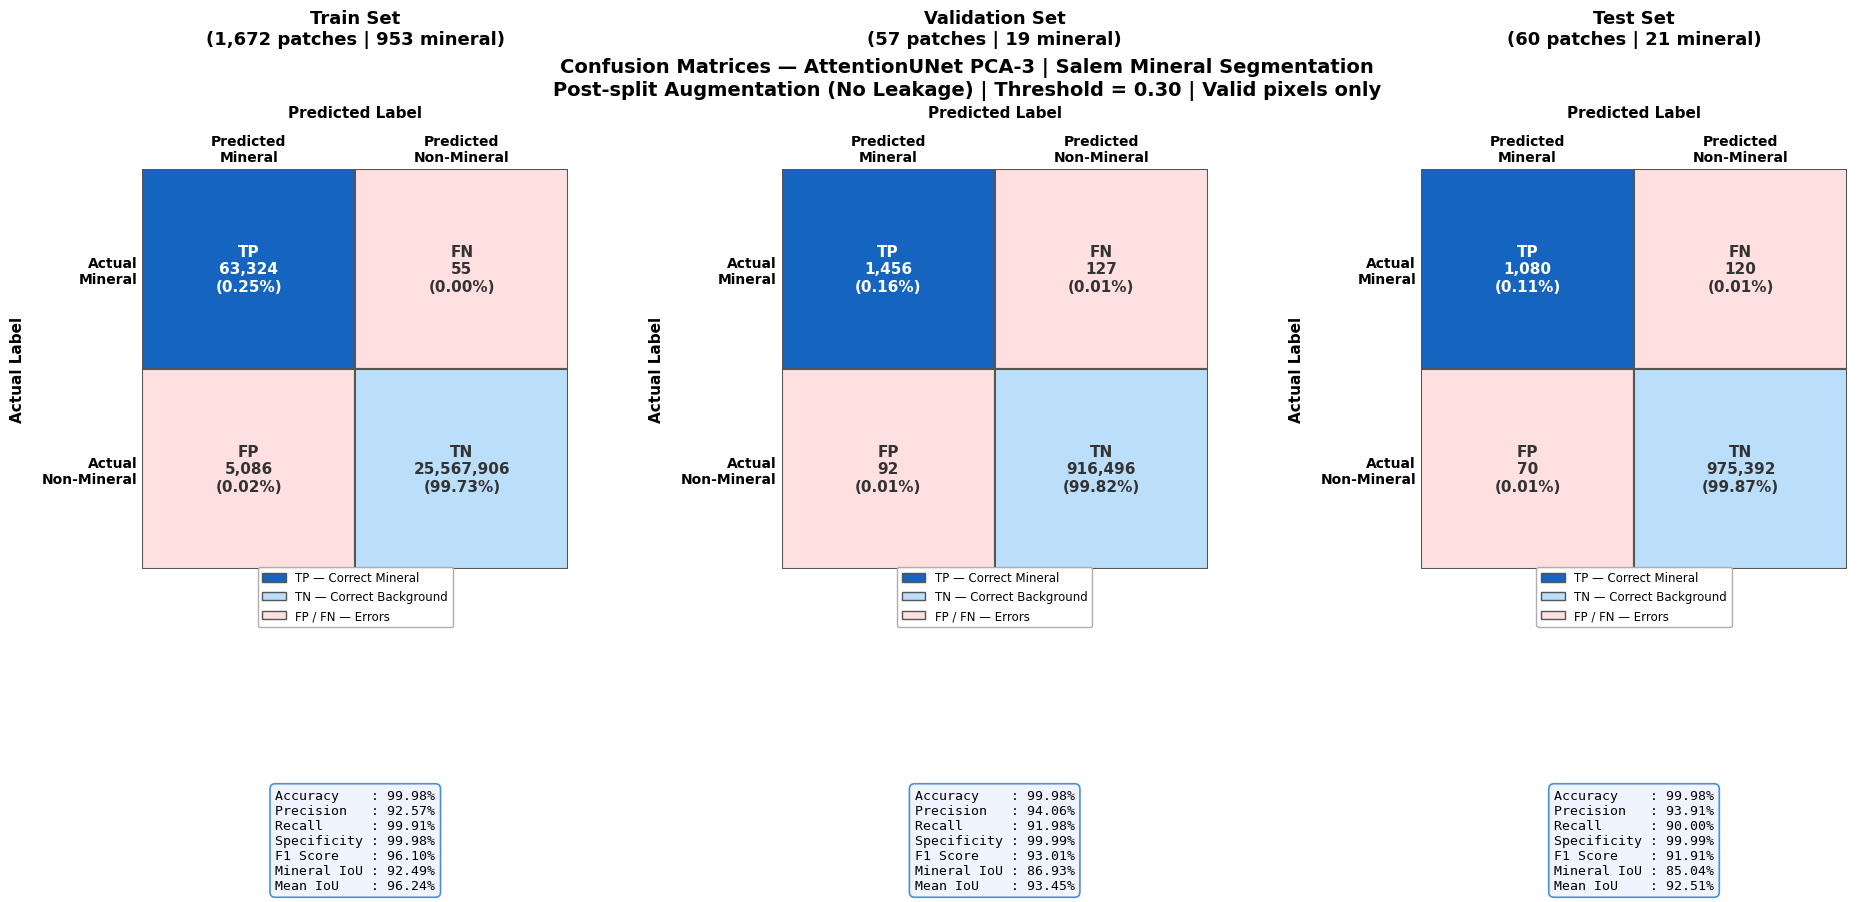


Saved: /content/drive/MyDrive/Project/LandSat_8/LC08_L2SP_143052_20230213_20230218_02_T1/results_pca/confusion_matrices_all_splits_pca.png


In [16]:
import matplotlib.ticker as mticker

# [FIX] collect_confusion unpacks (imgs, lbls, valids) and applies the valid
# mask so only real pixels contribute to TP/FP/FN/TN counts.

def collect_confusion(model, loader, threshold, device):
    """Accumulate TP/FP/FN/TN over an entire dataloader — valid pixels only."""
    model.eval()
    tp = fp = fn = tn = 0
    total_px = valid_px = 0

    with torch.no_grad():
        for imgs, lbls, valids in loader:   # [FIX] unpack three items
            imgs = imgs.to(device)
            lbls = lbls.to(device)

            probs     = torch.sigmoid(model(imgs))
            preds_bin = (probs > threshold).float()

            p = preds_bin.cpu().numpy().reshape(-1).astype(np.int32)
            t = lbls.cpu().numpy().reshape(-1).astype(np.int32)
            v = valids.cpu().numpy().reshape(-1).astype(bool)   # [FIX]

            total_px += len(v)
            valid_px += int(v.sum())

            # [FIX] restrict counts to valid pixels only
            p, t = p[v], t[v]

            tp += int(((p == 1) & (t == 1)).sum())
            fp += int(((p == 1) & (t == 0)).sum())
            fn += int(((p == 0) & (t == 1)).sum())
            tn += int(((p == 0) & (t == 0)).sum())

            del imgs, lbls, valids, probs, preds_bin
            torch.cuda.empty_cache()

    print(f"   {valid_px:,} / {total_px:,} pixels used "
          f"({valid_px/total_px*100:.1f}% valid, {total_px-valid_px:,} excluded)")
    return tp, fp, fn, tn


def metrics_from_cm(tp, fp, fn, tn, smooth=1e-8):
    precision   = (tp + smooth) / (tp + fp + smooth)
    recall      = (tp + smooth) / (tp + fn + smooth)
    f1          = 2 * precision * recall / (precision + recall + smooth)
    mineral_iou = (tp + smooth) / (tp + fp + fn + smooth)
    bg_iou      = (tn + smooth) / (tn + fp + fn + smooth)
    mean_iou    = (mineral_iou + bg_iou) / 2
    accuracy    = (tp + tn) / (tp + fp + fn + tn + smooth)
    specificity = (tn + smooth) / (tn + fp + smooth)
    return {
        'accuracy'   : float(accuracy),
        'precision'  : float(precision),
        'recall'     : float(recall),
        'specificity': float(specificity),
        'f1'         : float(f1),
        'mineral_iou': float(mineral_iou),
        'mean_iou'   : float(mean_iou),
    }


def plot_cm(ax, tp, fp, fn, tn, title, metrics):
    import matplotlib.patches as _mp

    total  = tp + fp + fn + tn + 1e-8
    pcts   = [[tp/total*100, fn/total*100],
              [fp/total*100, tn/total*100]]
    counts = [[tp, fn], [fp, tn]]
    names  = [["TP", "FN"], ["FP", "TN"]]

    DARK_BLUE  = "#1565C0"
    LIGHT_BLUE = "#BBDEFB"
    LIGHT_RED  = "#FFE0E0"
    cell_fc = [[DARK_BLUE,  LIGHT_RED],
               [LIGHT_RED,  LIGHT_BLUE]]
    txt_clr = [["white",   "#333333"],
               ["#333333", "#333333"]]

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    for row in range(2):
        for col in range(2):
            rect = _mp.FancyBboxPatch(
                (col - 0.5, row - 0.5), 1.0, 1.0,
                boxstyle="square,pad=0",
                facecolor=cell_fc[row][col],
                edgecolor="#555555", linewidth=1.5,
                transform=ax.transData, zorder=1
            )
            ax.add_patch(rect)
            ax.text(
                col, row,
                f"{names[row][col]}\n{counts[row][col]:,}\n({pcts[row][col]:.2f}%)",
                ha="center", va="center",
                fontsize=11, fontweight="bold",
                color=txt_clr[row][col], zorder=2
            )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Predicted\nMineral", "Predicted\nNon-Mineral"],
                       fontsize=10, fontweight="bold")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Actual\nMineral", "Actual\nNon-Mineral"],
                       fontsize=10, fontweight="bold")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Predicted Label", fontsize=11, fontweight="bold", labelpad=12)
    ax.set_ylabel("Actual Label",    fontsize=11, fontweight="bold", labelpad=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=44)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    legend_patches = [
        _mp.Patch(facecolor=DARK_BLUE,  edgecolor="#555", label="TP — Correct Mineral"),
        _mp.Patch(facecolor=LIGHT_BLUE, edgecolor="#555", label="TN — Correct Background"),
        _mp.Patch(facecolor=LIGHT_RED,  edgecolor="#555", label="FP / FN — Errors"),
    ]
    ax.legend(handles=legend_patches, loc="lower center",
              bbox_to_anchor=(0.5, -0.16), ncol=1,
              fontsize=8.5, framealpha=0.95, edgecolor="#aaa")

    metrics_text = (
        f"Accuracy    : {metrics['accuracy']*100:.2f}%\n"
        f"Precision   : {metrics['precision']*100:.2f}%\n"
        f"Recall      : {metrics['recall']*100:.2f}%\n"
        f"Specificity : {metrics['specificity']*100:.2f}%\n"
        f"F1 Score    : {metrics['f1']*100:.2f}%\n"
        f"Mineral IoU : {metrics['mineral_iou']*100:.2f}%\n"
        f"Mean IoU    : {metrics['mean_iou']*100:.2f}%"
    )
    ax.text(0.5, -0.55, metrics_text,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=9.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f4ff",
                      edgecolor="#4a90d9", linewidth=1.2))


# ── Collect confusion counts (valid pixels only)
print("Collecting predictions for Train set...")
tr_tp, tr_fp, tr_fn, tr_tn = collect_confusion(model, train_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

print("Collecting predictions for Val set...")
v_tp, v_fp, v_fn, v_tn = collect_confusion(model, val_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

print("Collecting predictions for Test set...")
t_tp, t_fp, t_fn, t_tn = collect_confusion(model, test_loader, BEST_THRESHOLD, DEVICE)
gc.collect(); torch.cuda.empty_cache()

# ── Compute metrics
tr_metrics = metrics_from_cm(tr_tp, tr_fp, tr_fn, tr_tn)
v_metrics  = metrics_from_cm(v_tp,  v_fp,  v_fn,  v_tn)
t_metrics  = metrics_from_cm(t_tp,  t_fp,  t_fn,  t_tn)

print(" CONFUSION MATRIX REPORT — PCA-3 AttentionUNet")
print(f" Threshold = {BEST_THRESHOLD:.2f}")
print(" Counts reflect valid (non-NaN) pixels only\n")

for split_name, tp, fp, fn, tn, m in [
    ("TRAIN", tr_tp, tr_fp, tr_fn, tr_tn, tr_metrics),
    ("VAL",   v_tp,  v_fp,  v_fn,  v_tn,  v_metrics),
    ("TEST",  t_tp,  t_fp,  t_fn,  t_tn,  t_metrics),
]:
    total = tp + fp + fn + tn
    print(f"\n── {split_name} SET ({total:,} valid pixels) ──")
    print(f"  True BG  → TN={tn:>12,}   FP={fp:>12,}")
    print(f"  True Min → FN={fn:>12,}   TP={tp:>12,}")
    print(f"\n  Accuracy    : {m['accuracy']*100:.4f}%")
    print(f"  Precision   : {m['precision']*100:.4f}%")
    print(f"  Recall      : {m['recall']*100:.4f}%")
    print(f"  Specificity : {m['specificity']*100:.4f}%")
    print(f"  F1 Score    : {m['f1']*100:.4f}%")
    print(f"  Mineral IoU : {m['mineral_iou']*100:.4f}%")
    print(f"  Mean IoU    : {m['mean_iou']*100:.4f}%")

# ── Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.subplots_adjust(bottom=0.38, wspace=0.5)

plot_cm(axes[0],
        tr_tp, tr_fp, tr_fn, tr_tn,
        f"Train Set\n({len(train_ds):,} patches | {int(train_tags.sum())} mineral)",
        tr_metrics)

plot_cm(axes[1],
        v_tp, v_fp, v_fn, v_tn,
        f"Validation Set\n({len(val_ds):,} patches | {int(val_tags.sum())} mineral)",
        v_metrics)

plot_cm(axes[2],
        t_tp, t_fp, t_fn, t_tn,
        f"Test Set\n({len(test_ds):,} patches | {int(test_tags.sum())} mineral)",
        t_metrics)

plt.suptitle(
    "Confusion Matrices — AttentionUNet PCA-3 | Salem Mineral Segmentation\n"
    f"Post-split Augmentation (No Leakage) | Threshold = {BEST_THRESHOLD:.2f} | "
    "Valid pixels only",
    fontsize=14, fontweight='bold', y=1.02
)

plt.savefig(RESULTS_DIR / 'confusion_matrices_all_splits_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {RESULTS_DIR / 'confusion_matrices_all_splits_pca.png'}")
